In [61]:
import matplotlib.pyplot as plt
import numpy as np
import random
from itertools import product, permutations, combinations

class EntropyDynamics():

    def __init__(self, no_attentions, att_prob, signal_duration, total_duration):  
        # Assuming uniform prior.
        # Assuming two levels of attention.
        # Have att_seq_indices instead of the whole sequence. Should be increasing order.
        self.att_prob = att_prob
        self.signal_duration = signal_duration
        self.total_duration = total_duration
        self.no_attentions = no_attentions

    def generate_all_binary_lists(self, inner_list_length):
        binary_combinations = list(product([0, 1], repeat=inner_list_length))
        result_lists = [list(combination) for combination in binary_combinations]
        return result_lists
    
    def generate_att_seq_indices_list(self):
        att_seq_indices_list = list(combinations(range(self.total_duration), self.no_attentions))
        att_seq_indices_list = [sorted(list(att_seq_indices)) for att_seq_indices in att_seq_indices_list]
        return att_seq_indices_list
    
    def compute_obs_likelihood(self, obs_so_far, candidate_signal_start, att_seq_indices):
            output = 1
            candidate_signal_states = list(range(candidate_signal_start, candidate_signal_start+ self.signal_duration))
            for att_ind in att_seq_indices:
                if att_ind >= len(obs_so_far):
                    break
                if att_ind in candidate_signal_states:
                    if obs_so_far[att_ind] == 1:
                        output *= self.att_prob
                    elif obs_so_far[att_ind] == 0:
                        output *= (1-self.att_prob)
                    else:
                        print('obs has to be either 0 or 1.')
                else:
                    if obs_so_far[att_ind] == 0:
                        output *= self.att_prob
                    elif obs_so_far[att_ind] == 1:
                        output *= (1-self.att_prob)
                    else:
                        print('obs has to be either 0 or 1.')
            return output
    
    def find_start_time_posterior(self, candidate_signal_start, obs_so_far, att_seq_indices):
            numerator = self.compute_obs_likelihood(obs_so_far, candidate_signal_start, att_seq_indices)
            denominator = 0
            for candidate_signal_start_prime in range(self.total_duration-self.signal_duration+1):
                
                if self.compute_obs_likelihood(obs_so_far, candidate_signal_start_prime, att_seq_indices) < 0:
                    print(f'Issue here {self.compute_obs_likelihood(obs_so_far, candidate_signal_start_prime, att_seq_indices)}')
                
                denominator += self.compute_obs_likelihood(obs_so_far, candidate_signal_start_prime, att_seq_indices)
            
            # if numerator > denominator:
            #     print(f'numerator is {numerator}')
            #     print(f'denominator is {denominator}')
            
            return numerator/denominator
    
    def find_belief(self, obs_so_far, att_seq_indices):
            belief = 0
            for ind in range(max(0, len(obs_so_far)-self.signal_duration), min(len(obs_so_far), self.total_duration-self.signal_duration + 1)):
                belief += self.find_start_time_posterior(ind, obs_so_far, att_seq_indices)
            return belief  
    
    def compute_present_signal_probs(self, obs_seq, att_seq_indices):
        belief_list = []
        for time in range(self.total_duration):
            belief_list.append(self.find_belief(obs_seq[:time+1], att_seq_indices))
        return belief_list

    def generate_obs_seq_and_corresp_prob(self, att_seq_indices):
        matching_obs_seqs = []
        matching_obs_seqs_probs = []
        possible_obs_seqs = self.generate_all_binary_lists(self.total_duration)
        for obs_seq in possible_obs_seqs:
            matching_obs_seqs.append(obs_seq)
            obs_seqs_probs = 0
            for signal_start in range(0, self.total_duration - self.signal_duration):
                obs_seqs_probs += self.compute_obs_likelihood(obs_seq, signal_start, att_seq_indices) * 1/(self.total_duration-self.signal_duration+1)
            matching_obs_seqs_probs.append(obs_seqs_probs)
        return matching_obs_seqs, matching_obs_seqs_probs

    def generate_att_seq_indices(self):
        att_seq_indices_list = self.generate_att_seq_indices_list()
        att_seq_indices_avg_entropy_list = []
        for att_seq_indices in att_seq_indices_list:
            matching_obs_seqs, matching_obs_seqs_probs = self.generate_obs_seq_and_corresp_prob(att_seq_indices)
            avg_entropy_array = np.zeros(self.total_duration)
            for ind in range(len(matching_obs_seqs)):
                belief_list = self.compute_present_signal_probs(matching_obs_seqs[ind], att_seq_indices)
                entropy_list = [-(belief * np.log(belief) + (1-belief) * np.log((1-belief))) for belief in belief_list]

                # if np.isnan(entropy_list[-1]):
                #     print(f'This belief caused the issue {belief_list[-1]}')

                avg_entropy_array += matching_obs_seqs_probs[ind] * np.array(entropy_list)
            att_seq_indices_avg_entropy_list.append(list(avg_entropy_array))
        return att_seq_indices_list, att_seq_indices_avg_entropy_list


In [78]:
entropy_dynamics = EntropyDynamics(no_attentions = 4, att_prob = .7, signal_duration = 2, total_duration = 10)
att_seq_indices_list, att_seq_indices_avg_entropy_list = entropy_dynamics.generate_att_seq_indices()

[1, 3, 5, 7]


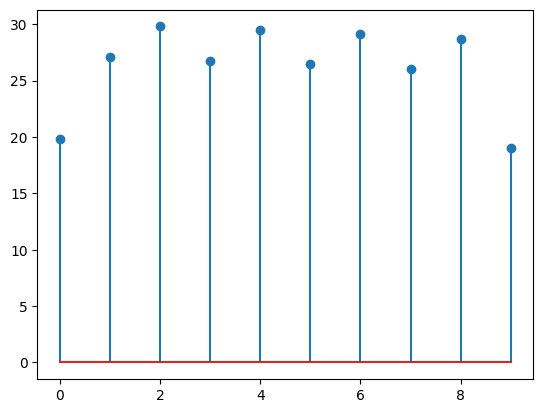

In [79]:
index_val = att_seq_indices_list.index([1,3,5,7])
print(att_seq_indices_list[index_val])
plt.stem(att_seq_indices_avg_entropy_list[index_val])
plt.show()

[1, 2, 3, 4]


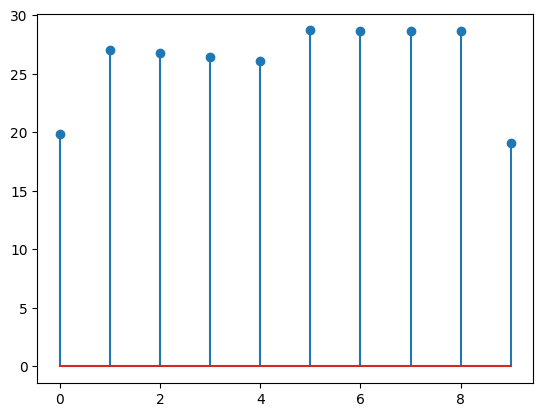

In [80]:
index_val = att_seq_indices_list.index([1,2,3,4])
print(att_seq_indices_list[index_val])
plt.stem(att_seq_indices_avg_entropy_list[index_val])
plt.show()

In [ ]:

# att_prob_list =[.6, .7, .8, .9]
att_prob_list =[.6]
# thresh_prob_list = [.4, .5, .6, .7, .8, .9]
# thresh_prob_list = [.1, .2, .3, .4, .5, .6]
thresh_prob_list = [.1, .2, .3]

# att_prob_list =[.6]
# thresh_prob_list = [.4]

# att_prob = .7
# thresh_prob = .4

signal_duration = 4
# signal_duration = 2

# total_duration = 20
# no_high_attentions = 10
total_duration = 12
no_high_attentions = 5

# runs_per_attention_seq = 100
runs_per_attention_seq = 1000
# runs_per_attention_seq = 10

attention_sequences_list = generate_attention_lists(no_high_attentions, total_duration, signal_duration)
dict = {} # {att_prob:{thresh_prob}}
dict['attention_sequences_list'] = attention_sequences_list
for att_prob in att_prob_list:
    dict[att_prob] = {}
    for thresh_prob in thresh_prob_list:
        avg_reward_list = []
        for attention_sequence in attention_sequences_list:
            tot_reward = 0
            for _ in range(runs_per_attention_seq):
                tot_reward += simulate(attention_sequence, thresh_prob, att_prob, total_duration, signal_duration)
            avg_reward_list.append(tot_reward/runs_per_attention_seq)
        dict[att_prob][thresh_prob] = avg_reward_list

# for ind in np.where(np.array(avg_reward_list) == max(avg_reward_list))[0]:
#     print(attention_sequences_list[ind])
# print(f'maximum reward is {max(avg_reward_list)}')

In [1]:




# Example usage:
inner_list_length = 3

result = generate_all_binary_lists(inner_list_length)
print(result)

[[0, 0, 0], [0, 0, 1], [0, 1, 0], [0, 1, 1], [1, 0, 0], [1, 0, 1], [1, 1, 0], [1, 1, 1]]


In [2]:
from itertools import product

def generate_all_sequences(inner_list_length, total_duration):
    # Generate all possible combinations of numbers between 0 and total_duration - 1 for the given inner list length
    sequence_combinations = list(product(range(total_duration), repeat=inner_list_length))

    # Convert the combinations to a list of lists
    result_lists = [list(sequence) for sequence in sequence_combinations]

    return result_lists

# Example usage:
inner_list_length = 2
total_duration = 3

result = generate_all_sequences(inner_list_length, total_duration)
print(result)

[[0, 0], [0, 1], [0, 2], [1, 0], [1, 1], [1, 2], [2, 0], [2, 1], [2, 2]]


[[0, 1], [0, 2], [1, 2]]
